In [29]:
import os
import time
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# =====================
# Configuration fixe
# =====================
CSV_PATH = "/home/cfouche/Téléchargements/BD_arbres_final_complet.csv"   # adapter le chemin si besoin
X_COLS = ["haut_tronc", "haut_tot", "tronc_diam"]
Y_COL = "age_estim"

# Modèles à entraîner (paramètres par défaut)
models = {
    "RandomForestRegressor": RandomForestRegressor(),
    "MLPRegressor": MLPRegressor(),
}

# =====================
# Chargement des données
# =====================
data = pd.read_csv(CSV_PATH)

# Nettoyage: convertit les chaînes vides/espace en NaN, puis force les colonnes utiles en numérique
data = data.replace(r"^\s*$", np.nan, regex=True)
for col in X_COLS + [Y_COL]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Garde uniquement les colonnes utiles et supprime les lignes incomplètes
data = data[X_COLS + [Y_COL]].dropna()

# Supprime les lignes où l'âge estimé vaut 2010
data = data[data[Y_COL] != 2010]

# Force explicitement toutes les colonnes explicatives en float avec 1 décimale
X = data[X_COLS].astype(float).round(1)
y = data[Y_COL]

# Export des colonnes d'entraînement (X + y) vers CSV
xy_export = pd.concat([X, y.rename(Y_COL)], axis=1)
xy_export = xy_export.dropna(how="all")
xy_export.to_csv("xy_training_dataset.csv", index=False)
print("CSV exporté: xy_training_dataset.csv")

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,train_size=0.8, test_size=0.2, random_state=421
)

# Standardisation (appliquée à tous les modèles, comme dans le script final)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# (optionnel) sauvegarde du scaler
os.makedirs("encoders", exist_ok=True)
with open("encoders/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# =====================
# Entraînement + évaluation
# =====================
results = {}
preds = {}

for model_name, model in models.items():
    print(f"\n=== {model_name} ===")
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test_scaled)
    preds[model_name] = {
        "y_true": y_test.values,
        "y_pred": y_pred
    }

    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2").mean()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Train score (R²): {train_score:.3f}")
    print(f"Test score  (R²): {test_score:.3f}")
    print(f"CV R² (5-fold):   {cv_r2:.3f}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R²:  {r2:.3f}")
    print(f"Temps entraînement: {train_time:.2f}s")

    results[model_name] = {
        "train_r2": train_score,
        "test_r2": test_score,
        "cv_r2": cv_r2,
        "mae": mae,
        "mse": mse,
        "r2": r2,
        "training_time_sec": train_time,
    }

# DataFrame récapitulatif
results_df = pd.DataFrame(results).T
print("\nRésumé :")
display(results_df)

CSV exporté: xy_training_dataset.csv

=== RandomForestRegressor ===
Train score (R²): 0.881
Test score  (R²): 0.685
CV R² (5-fold):   0.679
MAE: 7.30
MSE: 126.36
R²:  0.685
Temps entraînement: 0.56s

=== MLPRegressor ===


/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: M

Train score (R²): 0.668
Test score  (R²): 0.635
CV R² (5-fold):   0.662
MAE: 8.53
MSE: 146.33
R²:  0.635
Temps entraînement: 1.69s

Résumé :


/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,train_r2,test_r2,cv_r2,mae,mse,r2,training_time_sec
RandomForestRegressor,0.881205,0.684902,0.679100,7.303548,126.357427,0.684902,0.555657
MLPRegressor,0.668009,0.635107,0.661505,8.532540,146.325670,0.635107,1.692574


In [30]:
import os
import pickle

# Dossier de sortie
os.makedirs("models", exist_ok=True)

# Sauvegarde des modèles entraînés
for model_name, model in models.items():
    with open(f"models/regression_{model_name}.pkl", "wb") as f:
        pickle.dump(model, f)

print("✅ Modèles sauvegardés dans le dossier 'models/'")

os.makedirs("encoders", exist_ok=True)
with open("encoders/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Scaler sauvegardé dans 'encoders/scaler.pkl'")

✅ Modèles sauvegardés dans le dossier 'models/'
✅ Scaler sauvegardé dans 'encoders/scaler.pkl'


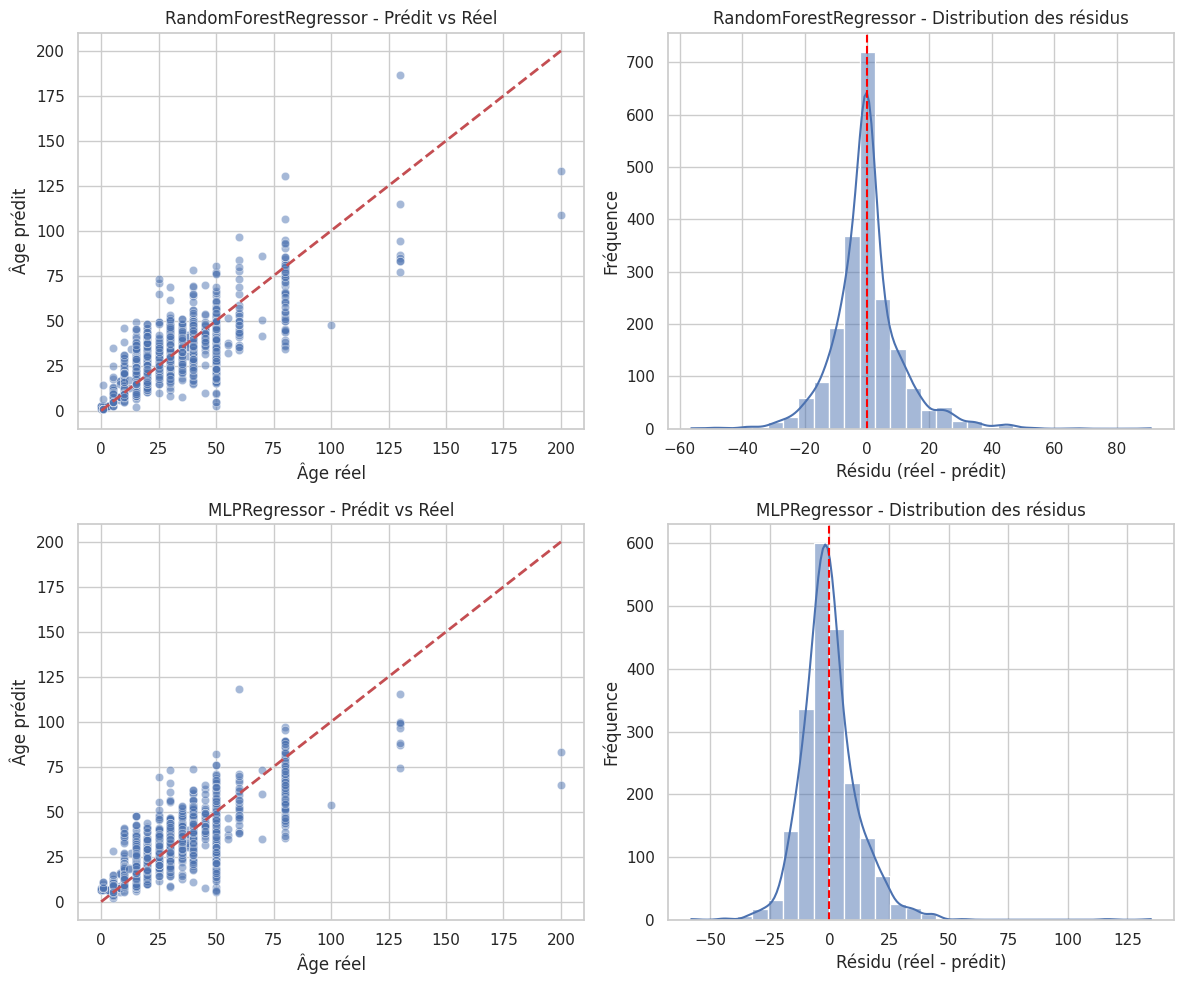

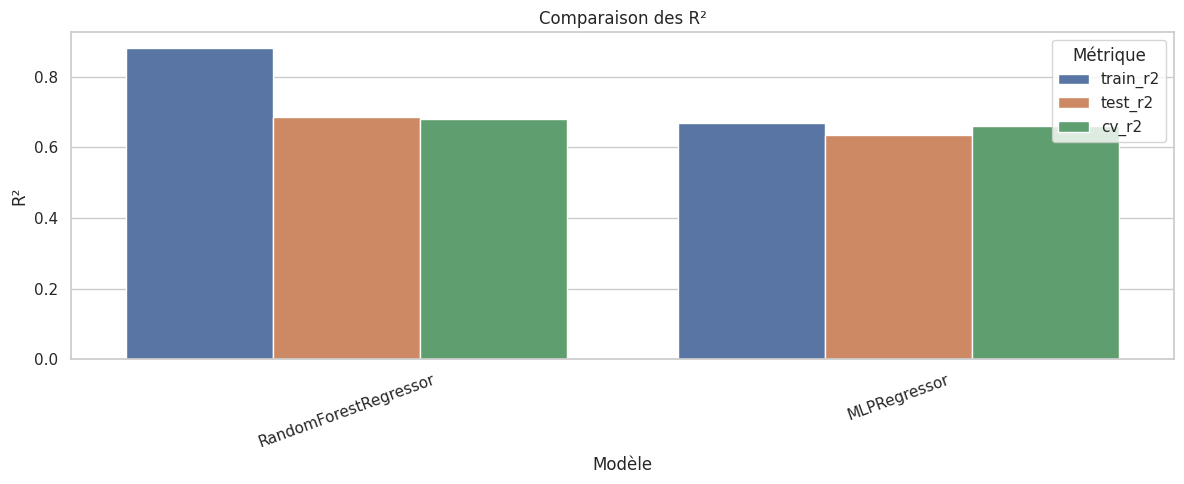

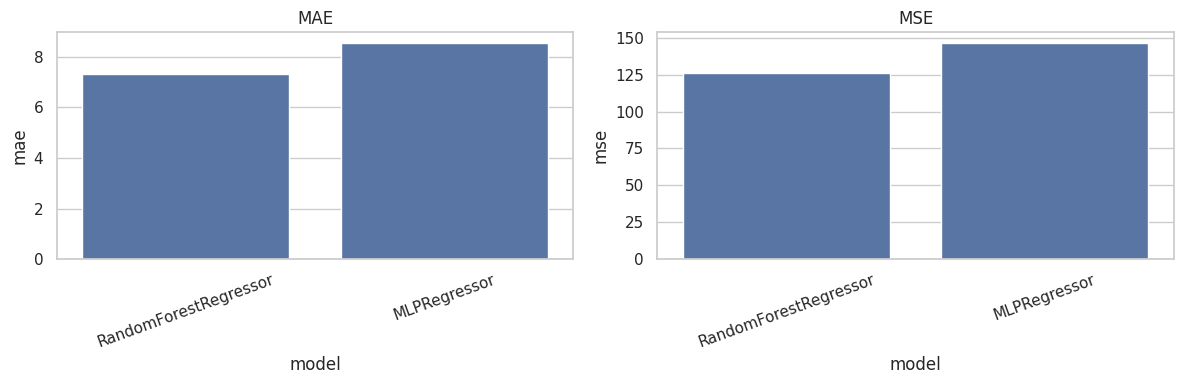

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sauvegarder les prédictions pendant l'entraînement
# (si pas déjà fait, ajoute dans ta boucle:)
# preds[model_name] = {"y_true": y_test.values, "y_pred": y_pred}

# Si tu ne l'as pas encore fait, crée ce dict avant la boucle:
# preds = {}

# -----------------------------------------------------------------------------
# Graphiques
# -----------------------------------------------------------------------------
sns.set(style="whitegrid")

# 1) Prédit vs Réel + résidus pour chaque modèle
n_models = len(models)
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))

if n_models == 1:
    axes = np.array([axes])  # normalise la forme

for i, model_name in enumerate(models.keys()):
    y_true = preds[model_name]["y_true"]
    y_pred = preds[model_name]["y_pred"]
    residuals = y_true - y_pred

    # Prédit vs Réel
    ax1 = axes[i, 0]
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, ax=ax1)
    min_v, max_v = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax1.plot([min_v, max_v], [min_v, max_v], "r--", lw=2)
    ax1.set_title(f"{model_name} - Prédit vs Réel")
    ax1.set_xlabel("Âge réel")
    ax1.set_ylabel("Âge prédit")

    # Résidus
    ax2 = axes[i, 1]
    sns.histplot(residuals, kde=True, bins=30, ax=ax2)
    ax2.axvline(0, color="red", linestyle="--")
    ax2.set_title(f"{model_name} - Distribution des résidus")
    ax2.set_xlabel("Résidu (réel - prédit)")
    ax2.set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

# 2) Comparaison des différents R²
results_df_plot = pd.DataFrame(results).T.reset_index().rename(columns={"index": "model"})
r2_long = results_df_plot.melt(
    id_vars="model",
    value_vars=["train_r2", "test_r2", "cv_r2"],
    var_name="metric",
    value_name="r2_value"
 )

plt.figure(figsize=(12, 5))
sns.barplot(data=r2_long, x="model", y="r2_value", hue="metric")
plt.title("Comparaison des R²")
plt.ylabel("R²")
plt.xlabel("Modèle")
plt.xticks(rotation=20)
plt.legend(title="Métrique")
plt.tight_layout()
plt.show()

# 3) Comparaison globale des erreurs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=results_df_plot, x="model", y="mae", ax=axes[0])
axes[0].set_title("MAE")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=results_df_plot, x="model", y="mse", ax=axes[1])
axes[1].set_title("MSE")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [32]:
# GridSearchCV pour optimiser les hyperparamètres
from sklearn.model_selection import GridSearchCV
import time

grid_configs = {
    "RandomForestRegressor": {
        "estimator": RandomForestRegressor(random_state=42),
        "param_grid": {
            'n_estimators': [50, 100],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'max_features': ['sqrt', 'log2']
        }
    },
    "MLPRegressor": {
        "estimator": MLPRegressor(random_state=42, max_iter=500),
        "param_grid": {
            'hidden_layer_sizes': [(50,), (100,)],
            'solver': ['adam', 'sgd'],
            'max_iter': [1000, 2000],
            'learning_rate': ['constant', 'adaptive']
        }
    }
}

grid_results = {}
best_models = {}

for model_name, cfg in grid_configs.items():
    print(f"\n=== GridSearchCV: {model_name} ===")
    start = time.time()
    grid = GridSearchCV(
        estimator=cfg["estimator"],
        param_grid=cfg["param_grid"],
        scoring="r2",
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train_scaled, y_train)
    grid_time = time.time() - start

    best_model = grid.best_estimator_
    best_models[model_name] = best_model

    y_pred = best_model.predict(X_test_scaled)
    train_score = best_model.score(X_train_scaled, y_train)
    test_score = best_model.score(X_test_scaled, y_test)
    cv_r2 = grid.best_score_

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    grid_results[model_name] = {
        "train_r2": train_score,
        "test_r2": test_score,
        "cv_r2": cv_r2,
        "mae": mae,
        "mse": mse,
        "r2": r2,
        "grid_search_time_sec": grid_time,
        "best_params": grid.best_params_
    }

    print(f"Train score (R²): {train_score:.3f}")
    print(f"Test score  (R²): {test_score:.3f}")
    print(f"CV R² (5-fold):   {cv_r2:.3f}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R²:  {r2:.3f}")
    print(f"Temps GridSearchCV: {grid_time:.2f}s")
    print(f"Best params: {grid.best_params_}")

grid_results_df = pd.DataFrame(grid_results).T
print("\nRésumé GridSearchCV:")
display(grid_results_df)

print("\nDétail des meilleurs paramètres:")
for model_name, res in grid_results.items():
    print(f"- {model_name}: {res['best_params']}")


=== GridSearchCV: RandomForestRegressor ===
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Train score (R²): 0.798
Test score  (R²): 0.711
CV R² (5-fold):   0.717
MAE: 7.39
MSE: 115.86
R²:  0.711
Temps GridSearchCV: 6.89s
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

=== GridSearchCV: MLPRegressor ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Train score (R²): 0.694
Test score  (R²): 0.652
CV R² (5-fold):   0.677
MAE: 8.30
MSE: 139.74
R²:  0.652
Temps GridSearchCV: 39.47s
Best params: {'hidden_layer_sizes': (100,), 'learning_rate': 'adaptive', 'max_iter': 1000, 'solver': 'sgd'}

Résumé GridSearchCV:


,train_r2,test_r2,cv_r2,mae,mse,r2,grid_search_time_sec,best_params
RandomForestRegressor,0.79761,0.711082,0.717208,7.387386,115.859122,0.711082,6.886156,"{'max_depth': 10, 'max_features': 'sqrt', 'min..."
MLPRegressor,0.694372,0.651532,0.677002,8.301249,139.739095,0.651532,39.472294,"{'hidden_layer_sizes': (100,), 'learning_rate'..."



Détail des meilleurs paramètres:
- RandomForestRegressor: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
- MLPRegressor: {'hidden_layer_sizes': (100,), 'learning_rate': 'adaptive', 'max_iter': 1000, 'solver': 'sgd'}


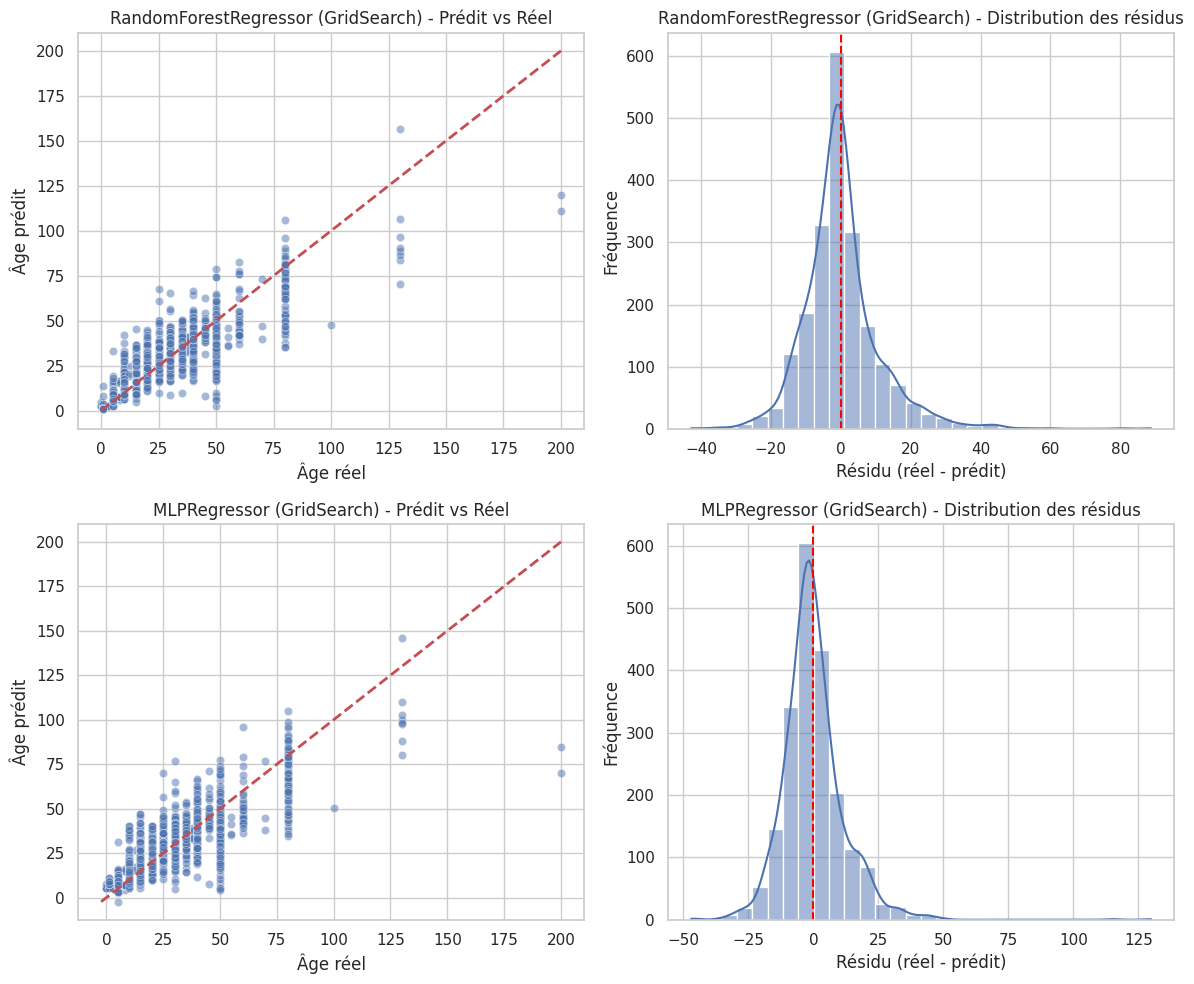

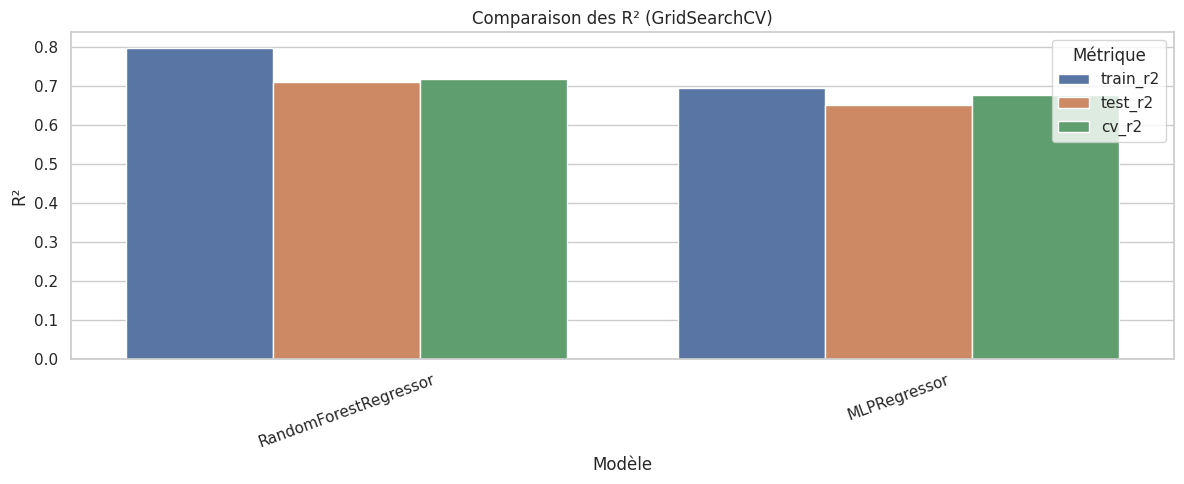

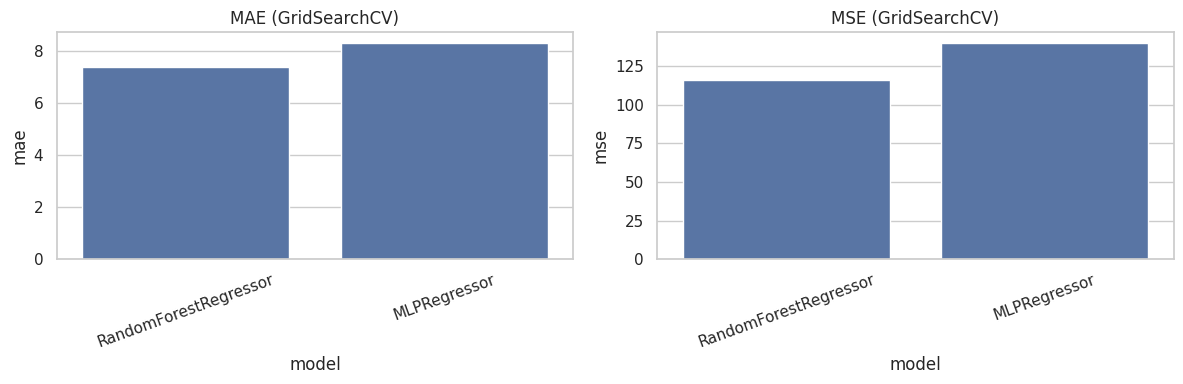

Modèles GridSearch sauvegardés dans models/
Scaler sauvegardé dans encoders/scaler.pkl


In [33]:
# Graphiques GridSearchCV + sauvegarde des meilleurs modèles
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Vérifie que la cellule GridSearchCV a bien été exécutée
if "best_models" not in globals() or "grid_results" not in globals():
    raise ValueError("Exécute d'abord la cellule 5 (GridSearchCV).")

sns.set(style="whitegrid")

# Prépare les prédictions des meilleurs modèles
grid_preds = {}
for model_name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    grid_preds[model_name] = {
        "y_true": y_test.values,
        "y_pred": y_pred
    }

# 1) Prédit vs Réel + résidus pour chaque meilleur modèle
n_models = len(best_models)
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))

if n_models == 1:
    axes = np.array([axes])

for i, model_name in enumerate(best_models.keys()):
    y_true = grid_preds[model_name]["y_true"]
    y_pred = grid_preds[model_name]["y_pred"]
    residuals = y_true - y_pred

    ax1 = axes[i, 0]
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, ax=ax1)
    min_v, max_v = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax1.plot([min_v, max_v], [min_v, max_v], "r--", lw=2)
    ax1.set_title(f"{model_name} (GridSearch) - Prédit vs Réel")
    ax1.set_xlabel("Âge réel")
    ax1.set_ylabel("Âge prédit")

    ax2 = axes[i, 1]
    sns.histplot(residuals, kde=True, bins=30, ax=ax2)
    ax2.axvline(0, color="red", linestyle="--")
    ax2.set_title(f"{model_name} (GridSearch) - Distribution des résidus")
    ax2.set_xlabel("Résidu (réel - prédit)")
    ax2.set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

# 2) Comparaison des différents R²
grid_results_df = pd.DataFrame(grid_results).T
r2_long_grid = grid_results_df.reset_index().rename(columns={"index": "model"}).melt(
    id_vars="model",
    value_vars=["train_r2", "test_r2", "cv_r2"],
    var_name="metric",
    value_name="r2_value"
 )

plt.figure(figsize=(12, 5))
sns.barplot(data=r2_long_grid, x="model", y="r2_value", hue="metric")
plt.title("Comparaison des R² (GridSearchCV)")
plt.ylabel("R²")
plt.xlabel("Modèle")
plt.xticks(rotation=20)
plt.legend(title="Métrique")
plt.tight_layout()
plt.show()

# 3) Comparaison globale des erreurs
grid_results_plot = grid_results_df.reset_index().rename(columns={"index": "model"})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=grid_results_plot, x="model", y="mae", ax=axes[0])
axes[0].set_title("MAE (GridSearchCV)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=grid_results_plot, x="model", y="mse", ax=axes[1])
axes[1].set_title("MSE (GridSearchCV)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Sauvegarde des meilleurs modèles issus de GridSearchCV
os.makedirs("models", exist_ok=True)
for model_name, model in best_models.items():
    with open(f"models/gridsearch_{model_name}.pkl", "wb") as f:
        pickle.dump(model, f)

print("Modèles GridSearch sauvegardés dans models/")

# Sauvegarde du scaler utilisé
os.makedirs("encoders", exist_ok=True)
with open("encoders/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaler sauvegardé dans encoders/scaler.pkl")

Comparaison baseline vs GridSearchCV:


,baseline_train_r2,baseline_test_r2,baseline_cv_r2,baseline_mae,baseline_mse,baseline_r2,grid_train_r2,grid_test_r2,grid_cv_r2,grid_mae,grid_mse,grid_r2,delta_test_r2,delta_cv_r2,delta_mae,delta_mse
MLPRegressor,0.668009,0.635107,0.661505,8.532540,146.325670,0.635107,0.694372,0.651532,0.677002,8.301249,139.739095,0.651532,0.016425,0.015497,-0.231292,-6.586576
RandomForestRegressor,0.881205,0.684902,0.679100,7.303548,126.357427,0.684902,0.79761,0.711082,0.717208,7.387386,115.859122,0.711082,0.02618,0.038108,0.083838,-10.498305


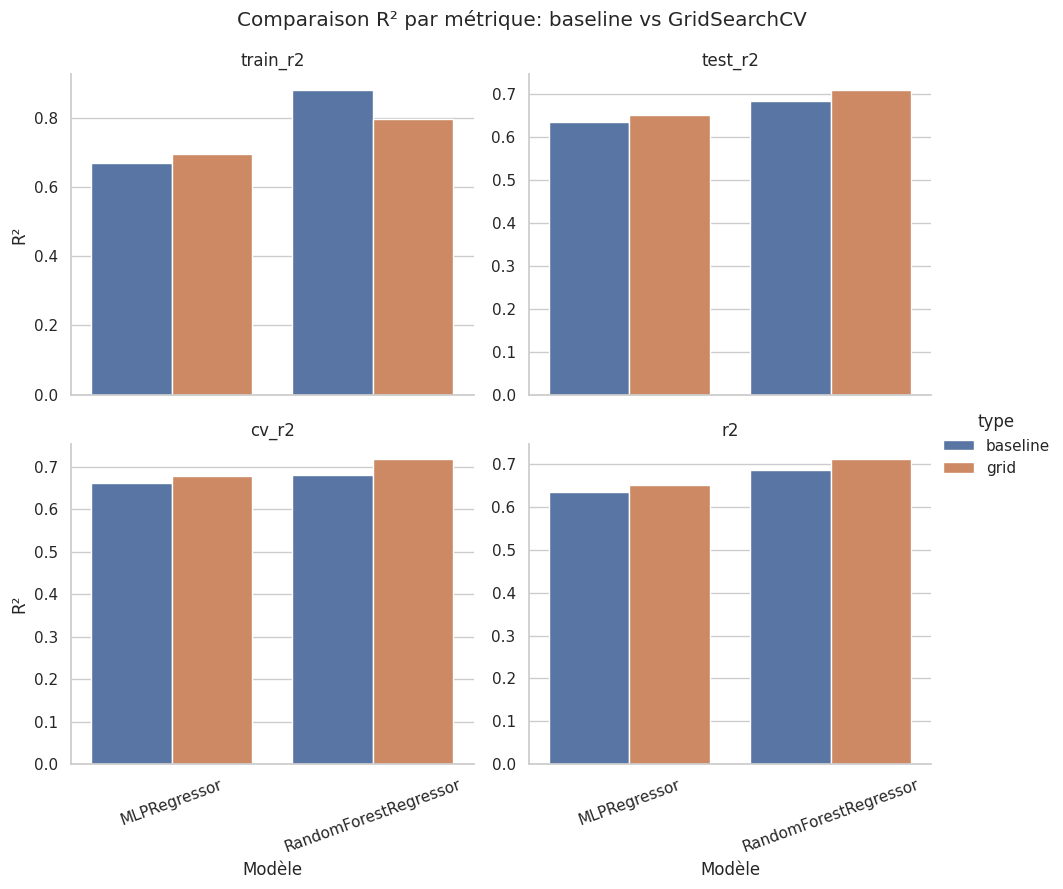

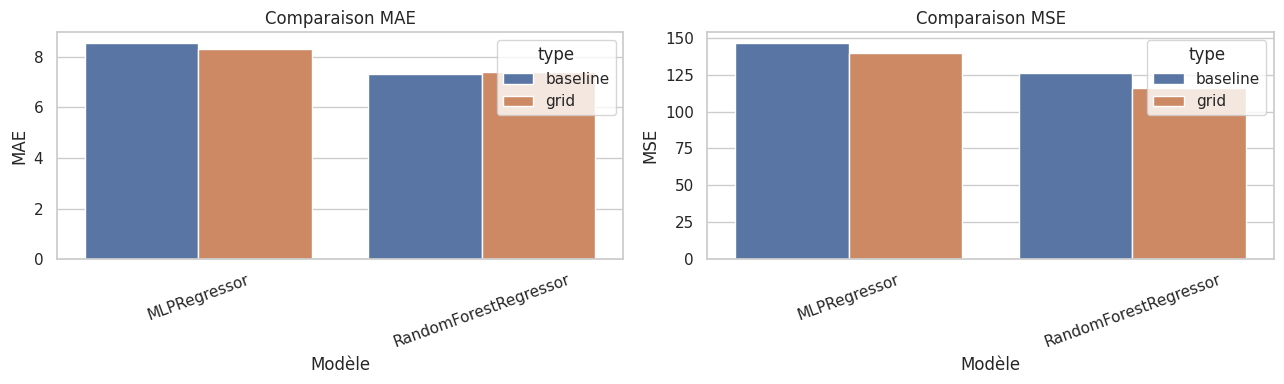

Lecture rapide:
- MLPRegressor: Δtest_r2=+0.0164, Δcv_r2=+0.0155, Δmae=-0.2313, Δmse=-6.5866
- RandomForestRegressor: Δtest_r2=+0.0262, Δcv_r2=+0.0381, Δmae=+0.0838, Δmse=-10.4983


In [34]:
# Comparaison: modèles par défaut vs modèles optimisés (GridSearchCV)
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if "results" not in globals() or "grid_results" not in globals():
    raise ValueError("Exécute d'abord la cellule 1 (baseline) et la cellule 5 (GridSearchCV).")

baseline_df = pd.DataFrame(results).T.copy()
grid_df = pd.DataFrame(grid_results).T.copy()

def normalize_model_name(name):
    s = str(name).lower()
    s = re.sub(r"[^a-z0-9]", "", s)
    return s

baseline_norm = {normalize_model_name(idx): idx for idx in baseline_df.index}
grid_norm = {normalize_model_name(idx): idx for idx in grid_df.index}
common_norm = sorted(set(baseline_norm.keys()).intersection(set(grid_norm.keys())))
metrics = ["train_r2", "test_r2", "cv_r2", "mae", "mse", "r2"]

if len(common_norm) > 0:
    baseline_models = [baseline_norm[k] for k in common_norm]
    grid_models = [grid_norm[k] for k in common_norm]
    display_names = baseline_models

    baseline_sel = baseline_df.loc[baseline_models].copy()
    grid_sel = grid_df.loc[grid_models].copy()
    baseline_sel.index = display_names
    grid_sel.index = display_names

else:
    print("Pas de noms communs entre baseline et GridSearchCV.")
    print("Comparaison fallback: meilleur baseline vs modèles GridSearch disponibles.")

    baseline_best_name = baseline_df["test_r2"].astype(float).idxmax()
    baseline_best_row = baseline_df.loc[baseline_best_name, metrics]

    display_names = list(grid_df.index)
    baseline_sel = pd.DataFrame([baseline_best_row.values] * len(display_names), columns=metrics, index=display_names)
    grid_sel = grid_df.loc[display_names, metrics].copy()

comparison = pd.concat(
    [
        baseline_sel[metrics].add_prefix("baseline_"),
        grid_sel[metrics].add_prefix("grid_")
    ],
    axis=1
 )

comparison["delta_test_r2"] = comparison["grid_test_r2"] - comparison["baseline_test_r2"]
comparison["delta_cv_r2"] = comparison["grid_cv_r2"] - comparison["baseline_cv_r2"]
comparison["delta_mae"] = comparison["grid_mae"] - comparison["baseline_mae"]
comparison["delta_mse"] = comparison["grid_mse"] - comparison["baseline_mse"]

print("Comparaison baseline vs GridSearchCV:")
display(comparison)

rows = []
for model_name in display_names:
    for metric in metrics:
        rows.append({
            "model": model_name,
            "metric": metric,
            "type": "baseline",
            "value": baseline_sel.loc[model_name, metric]
        })
        rows.append({
            "model": model_name,
            "metric": metric,
            "type": "grid",
            "value": grid_sel.loc[model_name, metric]
        })

plot_df = pd.DataFrame(rows)
sns.set(style="whitegrid")

# 1) R² séparé par métrique
r2_metrics = ["train_r2", "test_r2", "cv_r2", "r2"]
r2_plot = plot_df[plot_df["metric"].isin(r2_metrics)].copy()
r2_plot["metric"] = pd.Categorical(r2_plot["metric"], categories=r2_metrics, ordered=True)

g = sns.catplot(
    data=r2_plot,
    kind="bar",
    x="model",
    y="value",
    hue="type",
    col="metric",
    col_wrap=2,
    sharey=False,
    height=4,
    aspect=1.2,
    errorbar=None
 )
g.set_axis_labels("Modèle", "R²")
g.set_titles("{col_name}")
for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(20)
g.fig.suptitle("Comparaison R² par métrique: baseline vs GridSearchCV", y=1.03)
plt.show()

# 2) Erreurs (plus bas = mieux)
err_plot = plot_df[plot_df["metric"].isin(["mae", "mse"])]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=err_plot[err_plot["metric"] == "mae"], x="model", y="value", hue="type", errorbar=None, ax=axes[0])
axes[0].set_title("Comparaison MAE")
axes[0].set_xlabel("Modèle")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=err_plot[err_plot["metric"] == "mse"], x="model", y="value", hue="type", errorbar=None, ax=axes[1])
axes[1].set_title("Comparaison MSE")
axes[1].set_xlabel("Modèle")
axes[1].set_ylabel("MSE")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print("Lecture rapide:")
for model_name in display_names:
    dt = comparison.loc[model_name, "delta_test_r2"]
    dcv = comparison.loc[model_name, "delta_cv_r2"]
    dmae = comparison.loc[model_name, "delta_mae"]
    dmse = comparison.loc[model_name, "delta_mse"]
    print(f"- {model_name}: Δtest_r2={dt:+.4f}, Δcv_r2={dcv:+.4f}, Δmae={dmae:+.4f}, Δmse={dmse:+.4f}")

In [ ]:
# Cell 8: comparaison avec/sans nomfrancais (baseline + GridSearchCV)
import os
import time
import pickle
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

CSV_PATH = "/home/cfouche/Téléchargements/BD_arbres_final_complet.csv"
NUM_COLS = ["haut_tronc", "haut_tot", "tronc_diam"]
CAT_COL = "nomfrancais"
TARGET_COL = "age_estim"

# Chargement + nettoyage aligné avec le reste du notebook
df = pd.read_csv(CSV_PATH)
df = df.replace(r"^\s*$", np.nan, regex=True)

for col in NUM_COLS + [TARGET_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[NUM_COLS + [CAT_COL, TARGET_COL]].copy()
df = df.dropna(subset=NUM_COLS + [TARGET_COL])
df = df[df[TARGET_COL] != 2010]
df[NUM_COLS] = df[NUM_COLS].astype(float).round(1)
def normalize_nomfrancais(value):
    if pd.isna(value):
        return "UNKNOW"

    text = str(value).strip()
    if text == "Indéterminé":
        text = "UNKNOW"

    cleaned = "".join(char for char in text if not char.islower())
    return cleaned if cleaned else "UNKNOW"

df[CAT_COL] = df[CAT_COL].apply(normalize_nomfrancais)

# Split unique pour comparer équitablement les scénarios
idx_train, idx_test = train_test_split(df.index, train_size=0.8, test_size=0.2, random_state=421)
y_train = df.loc[idx_train, TARGET_COL]
y_test = df.loc[idx_test, TARGET_COL]

scenarios = {
    "without_nomfrancais": NUM_COLS,
    "with_nomfrancais": NUM_COLS + [CAT_COL],
}

results_rows = []

# Sauvegarde des pipelines entraînés avec nomfrancais
os.makedirs("models", exist_ok=True)
nomfrancais_models = {"baseline": {}, "gridsearch": {}}

for scenario_name, feature_cols in scenarios.items():
    print(f"\n===== Scenario: {scenario_name} =====")

    X_train = df.loc[idx_train, feature_cols]
    X_test = df.loc[idx_test, feature_cols]

    # Preprocessing
    transformers = [("num", StandardScaler(), NUM_COLS)]
    if CAT_COL in feature_cols:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), [CAT_COL]))
    preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

    # Baseline models
    baseline_models = {
        "RandomForestRegressor": RandomForestRegressor(),
        "MLPRegressor": MLPRegressor(),
    }

    for model_name, estimator in baseline_models.items():
        baseline_pipeline = Pipeline([
            ("preprocess", preprocess),
            ("model", estimator),
        ])

        start = time.time()
        baseline_pipeline.fit(X_train, y_train)
        train_time = time.time() - start

        if scenario_name == "with_nomfrancais":
            nomfrancais_models["baseline"][model_name] = baseline_pipeline
            with open(f"models/nomfrancais_baseline_{model_name}.pkl", "wb") as f:
                pickle.dump(baseline_pipeline, f)

        y_pred = baseline_pipeline.predict(X_test)
        train_r2 = baseline_pipeline.score(X_train, y_train)
        test_r2 = baseline_pipeline.score(X_test, y_test)
        cv_r2 = cross_val_score(baseline_pipeline, X_train, y_train, cv=5, scoring="r2", n_jobs=-1).mean()
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results_rows.append({
            "scenario": scenario_name,
            "method": "baseline",
            "model": model_name,
            "train_r2": train_r2,
            "test_r2": test_r2,
            "cv_r2": cv_r2,
            "mae": mae,
            "mse": mse,
            "r2": r2,
            "time_sec": train_time,
            "best_params": None,
        })

    # GridSearchCV models
    grid_configs = {
        "RandomForestRegressor": {
            "estimator": RandomForestRegressor(random_state=42),
            "param_grid": {
                "model__n_estimators": [50, 100],
                "model__max_depth": [None, 10],
                "model__min_samples_split": [2, 5],
            },
        },
        "MLPRegressor": {
            "estimator": MLPRegressor(random_state=42),
            "param_grid": {
                "model__hidden_layer_sizes": [(50,), (100,)],
                "model__solver": ["adam", "sgd"],
                "model__learning_rate": ["constant", "adaptive"],
                "model__max_iter": [1000],
            },
        },
    }

    for model_name, cfg in grid_configs.items():
        grid_pipeline = Pipeline([
            ("preprocess", preprocess),
            ("model", cfg["estimator"]),
        ])

        start = time.time()
        grid = GridSearchCV(
            estimator=grid_pipeline,
            param_grid=cfg["param_grid"],
            scoring="r2",
            cv=5,
            n_jobs=-1,
            verbose=0,
        )
        grid.fit(X_train, y_train)
        grid_time = time.time() - start

        best_model = grid.best_estimator_
        if scenario_name == "with_nomfrancais":
            nomfrancais_models["gridsearch"][model_name] = best_model
            with open(f"models/nomfrancais_gridsearch_{model_name}.pkl", "wb") as f:
                pickle.dump(best_model, f)

        y_pred = best_model.predict(X_test)
        train_r2 = best_model.score(X_train, y_train)
        test_r2 = best_model.score(X_test, y_test)
        cv_r2 = grid.best_score_
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results_rows.append({
            "scenario": scenario_name,
            "method": "gridsearch",
            "model": model_name,
            "train_r2": train_r2,
            "test_r2": test_r2,
            "cv_r2": cv_r2,
            "mae": mae,
            "mse": mse,
            "r2": r2,
            "time_sec": grid_time,
            "best_params": grid.best_params_,
        })

# Résultats détaillés
cell8_results_df = pd.DataFrame(results_rows)
print("Résultats détaillés (baseline + gridsearch, avec/sans nomfrancais):")
display(cell8_results_df.sort_values(["method", "model", "scenario"]))

# Tableau comparatif: effet de l'ajout de nomfrancais
compare_cols = ["train_r2", "test_r2", "cv_r2", "mae", "mse", "r2", "time_sec"]
pivot_df = cell8_results_df.pivot_table(
    index=["method", "model"],
    columns="scenario",
    values=compare_cols,
    aggfunc="first"
 )

for c in ["train_r2", "test_r2", "cv_r2", "r2"]:
    pivot_df[("delta_with_minus_without", c)] = pivot_df[(c, "with_nomfrancais")] - pivot_df[(c, "without_nomfrancais")]
for c in ["mae", "mse", "time_sec"]:
    pivot_df[("delta_with_minus_without", c)] = pivot_df[(c, "with_nomfrancais")] - pivot_df[(c, "without_nomfrancais")]

pivot_df = pivot_df.sort_index(axis=1)
print("\nComparaison avec - sans nomfrancais (par méthode et modèle):")
display(pivot_df)

print("\nModèles sauvegardés pour with_nomfrancais dans models/:")
for method_name, model_dict in nomfrancais_models.items():
    for model_name in model_dict.keys():
        print(f"- nomfrancais_{method_name}_{model_name}.pkl")


===== Scenario: without_nomfrancais =====


/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: M


===== Scenario: with_nomfrancais =====


/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/cfouche/Documents/Code/Projet_BigDataIAWeb/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: M

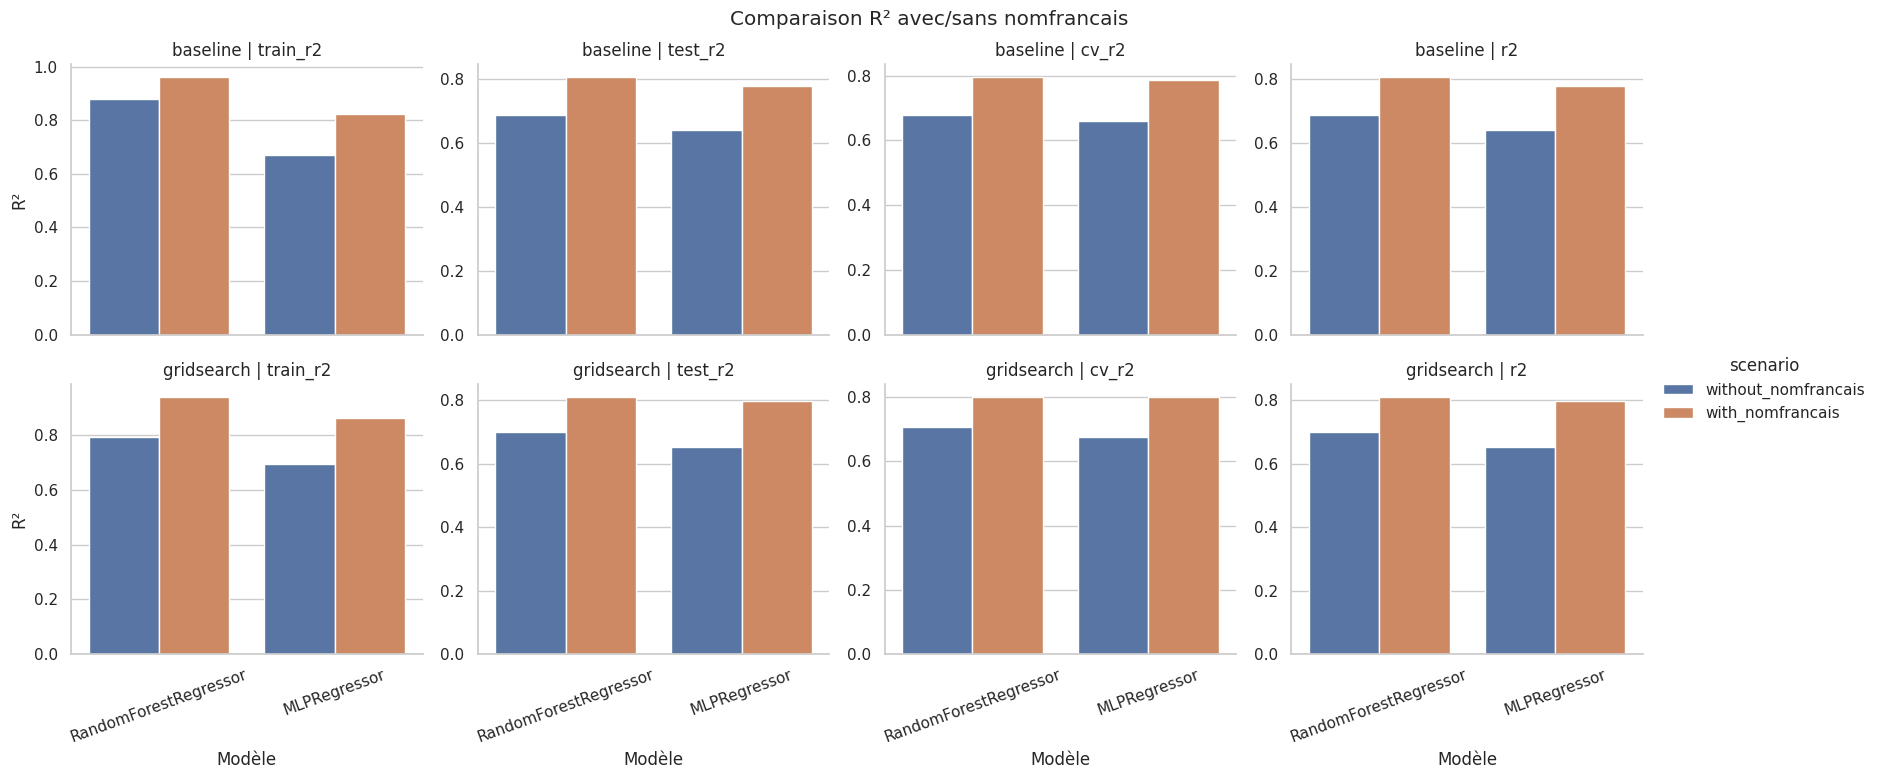

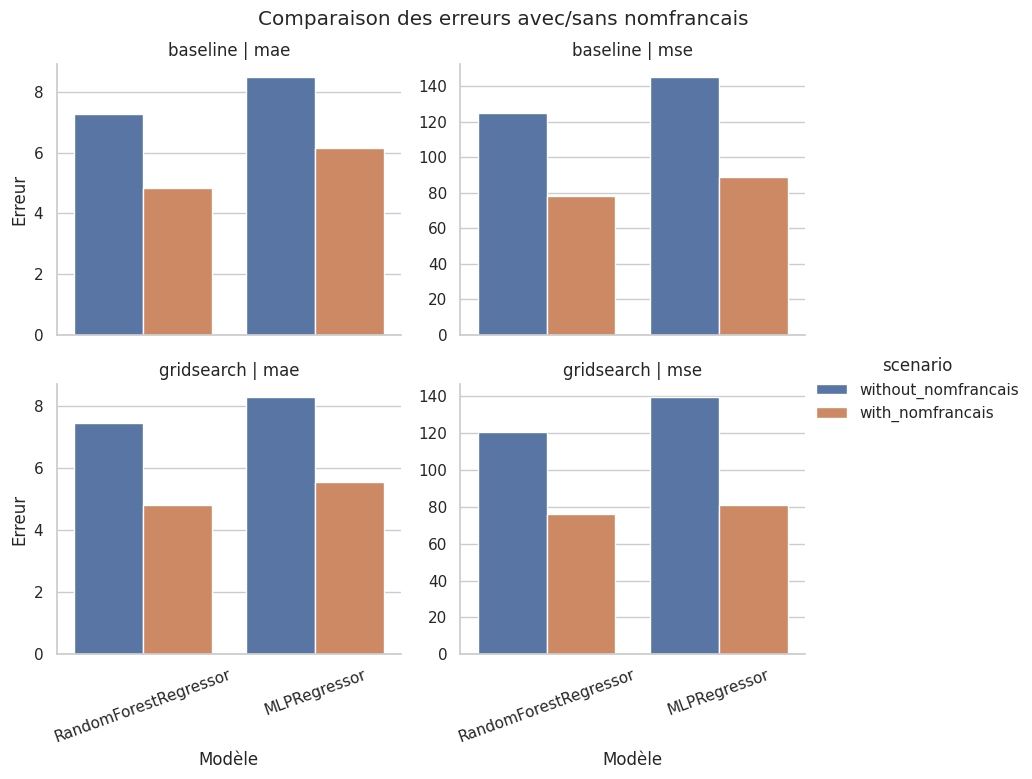

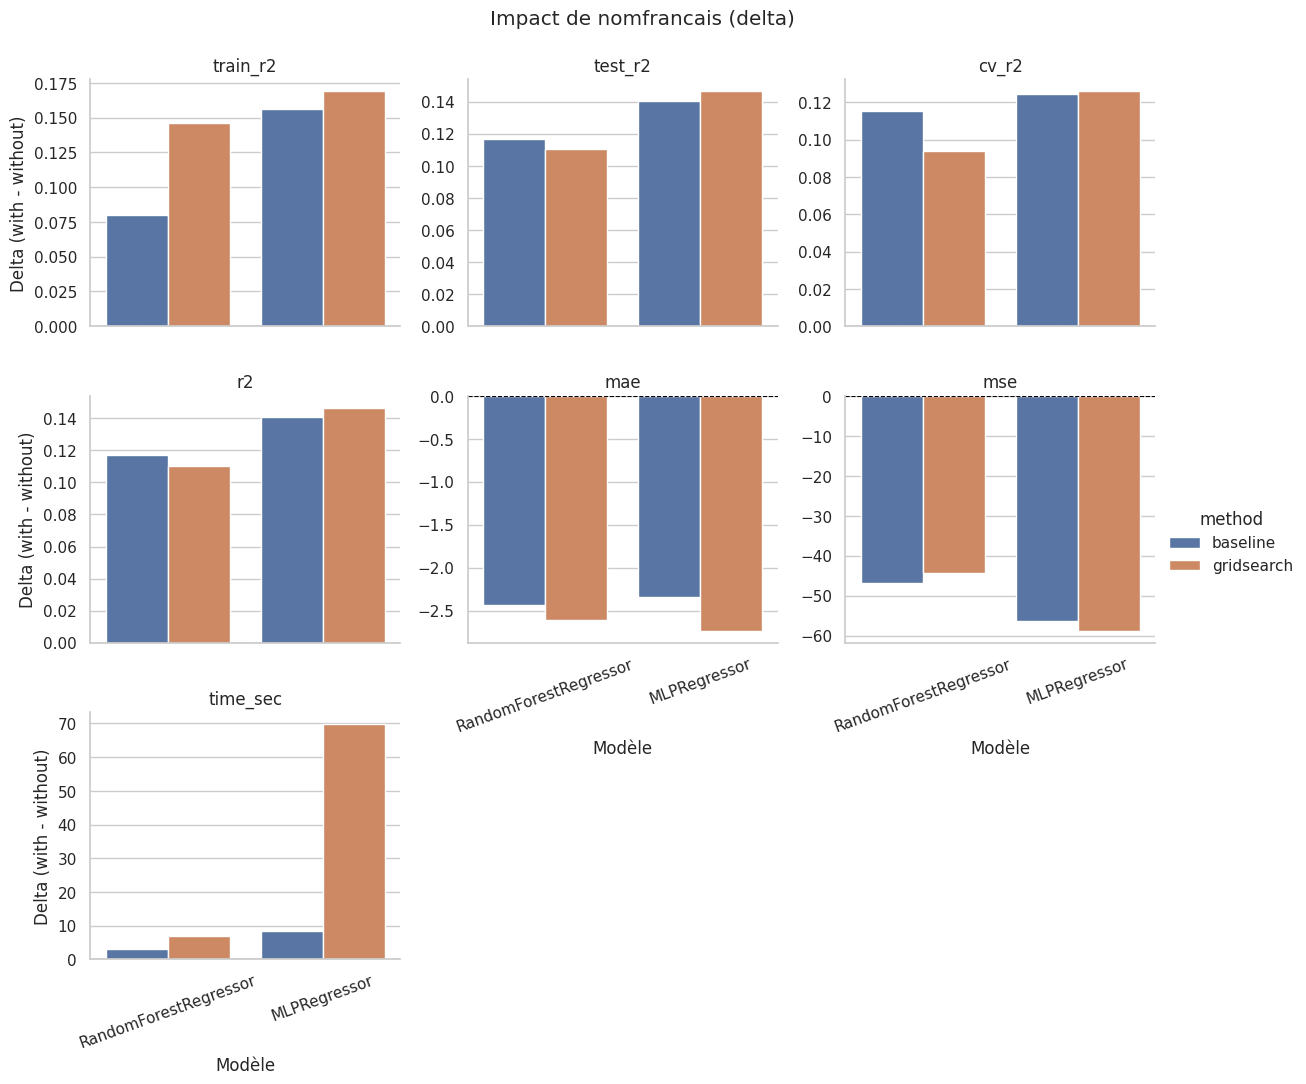

Rappel lecture delta:
- R²: delta positif = amélioration avec nomfrancais
- MAE/MSE: delta négatif = amélioration avec nomfrancais
- time_sec: delta positif = plus lent avec nomfrancais


In [41]:
# Cell 9: visualisation de la comparaison (cellule 8)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if "cell8_results_df" not in globals():
    raise ValueError("Exécute d'abord la cellule 8 pour générer cell8_results_df.")

viz_df = cell8_results_df.copy()
sns.set(style="whitegrid")

# 1) R² par scénario/méthode/modèle
r2_metrics = ["train_r2", "test_r2", "cv_r2", "r2"]
r2_long = viz_df.melt(
    id_vars=["scenario", "method", "model"],
    value_vars=r2_metrics,
    var_name="metric",
    value_name="value"
 )

g1 = sns.catplot(
    data=r2_long,
    kind="bar",
    x="model",
    y="value",
    hue="scenario",
    col="metric",
    row="method",
    sharey=False,
    height=3.5,
    aspect=1.2,
    errorbar=None
 )
g1.set_axis_labels("Modèle", "R²")
g1.set_titles("{row_name} | {col_name}")
for ax in g1.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(20)
g1.fig.suptitle("Comparaison R² avec/sans nomfrancais", y=1.02)
plt.show()

# 2) Erreurs MAE/MSE par scénario/méthode/modèle
err_metrics = ["mae", "mse"]
err_long = viz_df.melt(
    id_vars=["scenario", "method", "model"],
    value_vars=err_metrics,
    var_name="metric",
    value_name="value"
 )

g2 = sns.catplot(
    data=err_long,
    kind="bar",
    x="model",
    y="value",
    hue="scenario",
    col="metric",
    row="method",
    sharey=False,
    height=3.5,
    aspect=1.2,
    errorbar=None
 )
g2.set_axis_labels("Modèle", "Erreur")
g2.set_titles("{row_name} | {col_name}")
for ax in g2.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(20)
g2.figure.suptitle("Comparaison des erreurs avec/sans nomfrancais", y=1.02)
plt.show()

# 3) Delta (with - without) pour lecture rapide
base_cols = ["method", "model"]
with_df = viz_df[viz_df["scenario"] == "with_nomfrancais"].set_index(base_cols)
without_df = viz_df[viz_df["scenario"] == "without_nomfrancais"].set_index(base_cols)

delta_cols = ["train_r2", "test_r2", "cv_r2", "r2", "mae", "mse", "time_sec"]
delta_df = (with_df[delta_cols] - without_df[delta_cols]).reset_index()
delta_long = delta_df.melt(
    id_vars=["method", "model"],
    value_vars=delta_cols,
    var_name="metric",
    value_name="delta_with_minus_without"
 )

g3 = sns.catplot(
    data=delta_long,
    kind="bar",
    x="model",
    y="delta_with_minus_without",
    hue="method",
    col="metric",
    col_wrap=3,
    sharey=False,
    height=3.3,
    aspect=1.2,
    errorbar=None
 )
for ax in g3.axes.flatten():
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    for label in ax.get_xticklabels():
        label.set_rotation(20)
g3.set_axis_labels("Modèle", "Delta (with - without)")
g3.set_titles("{col_name}")
g3.figure.suptitle("Impact de nomfrancais (delta)", y=1.03)
plt.show()

print("Rappel lecture delta:")
print("- R²: delta positif = amélioration avec nomfrancais")
print("- MAE/MSE: delta négatif = amélioration avec nomfrancais")
print("- time_sec: delta positif = plus lent avec nomfrancais")